<a href="https://colab.research.google.com/github/Fathzzzzz/thesigmajourney/blob/main/punyatenns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Import Data set From Kaggel

In [26]:
import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()
path = kagglehub.competition_download('dmai-oprec-2025')

Kaggle credentials set.
Kaggle credentials successfully validated.


# 1. Introduction & Objectives
Goal: Memprediksi cuaca cerah atau hujan berdasarkan fitur  Parameter suhu dan kelembapan, Presipitasi dan Kode cuaca, Tekanan dan atmosfer, Tutupan Awan, Radiasi dan Evapotranspirasi dan Angin. dievaluasi menggunakan metrik Root Mean Squared Error (RMSE). RMSE mengukur rata-rata dari akar kuadrat selisih antara nilai prediksi dan nilai aktual.


# 2. Import library

In [20]:
import pandas as pd
import numpy as np
import re
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from tqdm.auto import tqdm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from lightgbm import early_stopping, log_evaluation
import optuna
import random

seed_value = 37
np.random.seed(seed_value)
random.seed(seed_value)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

tqdm.pandas()

# 3. Load Raw Data dan Initial Check
Bertujuan untuk Memvalidasi struktur dan tipe data pada setiap kolom untuk memastikan kesesuaian antara fitur atmosfer dengan target prediksi. Memahami distribusi awal data guna menentukan strategi feature engineering dan pembersihan data yang paling tepat untuk menekan skor RMSE.

In [32]:
!pip install kaggle

In [39]:

BASE_PATH = path


df_sample_submission = pd.read_csv(BASE_PATH + "/sample_submission.csv")
df_test = pd.read_csv(BASE_PATH + "/test.csv")
df_train = pd.read_csv(BASE_PATH + "/train.csv")

# 4. EDA (Exploratory Data Analysis)
Exploratory Data Analysis dilakukan untuk membedah hubungan antara variabel atmosfer seperti kelembapan dan tekanan udara guna mengidentifikasi pola terkuat yang memicu terjadinya hujan. Tahap ini juga berfungsi untuk memvisualisasikan distribusi data dan tren waktu pada setiap wilayah agar model dapat memahami karakteristik cuaca yang berbeda secara spasial maupun temporal. Melalui analisis ini, anomali pada kode cuaca dan fitur lainnya dapat dideteksi lebih dini sehingga strategi transformasi fitur yang dipilih mampu secara efektif meminimalkan nilai RMSE pada prediksi akhir.

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 4.1 Statistik Deskriptif Target
Statistik deskriptif pada variabel target bertujuan untuk memahami karakteristik utama dari probabilitas hujan, mulai dari nilai rata-rata hingga sebaran datanya secara keseluruhan. Analisis ini mengungkapkan kecenderungan sentral dan rentang nilai aktual guna mengidentifikasi apakah data target memiliki kemiringan distribusi atau konsentrasi nilai pada tingkat probabilitas tertentu. Hasil observasi ini menjadi acuan penting bagi model ensemble dalam mengenali ambang batas hujan dan memastikan bahwa prediksi akhir tetap berada dalam skala logis nol hingga seratus persen.

In [ ]:
target_col = 'precipitation_probability (%)'
print(f"Statistik Deskriptif untuk {target_col}:")
print(df_train[target_col].describe())

missing = df_train[target_col].isnull().sum()
print(f"\nJumlah Missing Values: {missing}")

Statistik Deskriptif untuk precipitation_probability (%):
count    6528.000000
mean       23.867034
std        25.053895
min         0.000000
25%         3.000000
50%        15.000000
75%        38.000000
max       100.000000
Name: precipitation_probability (%), dtype: float64

Jumlah Missing Values: 0


### 4.1.1 Visualisasi Distribusi
Visualisasi distribusi target dilakukan menggunakan histogram dan density plot untuk mengamati apakah probabilitas hujan tersebar merata atau terkonsentrasi pada nilai-nilai tertentu seperti nol dan seratus persen.

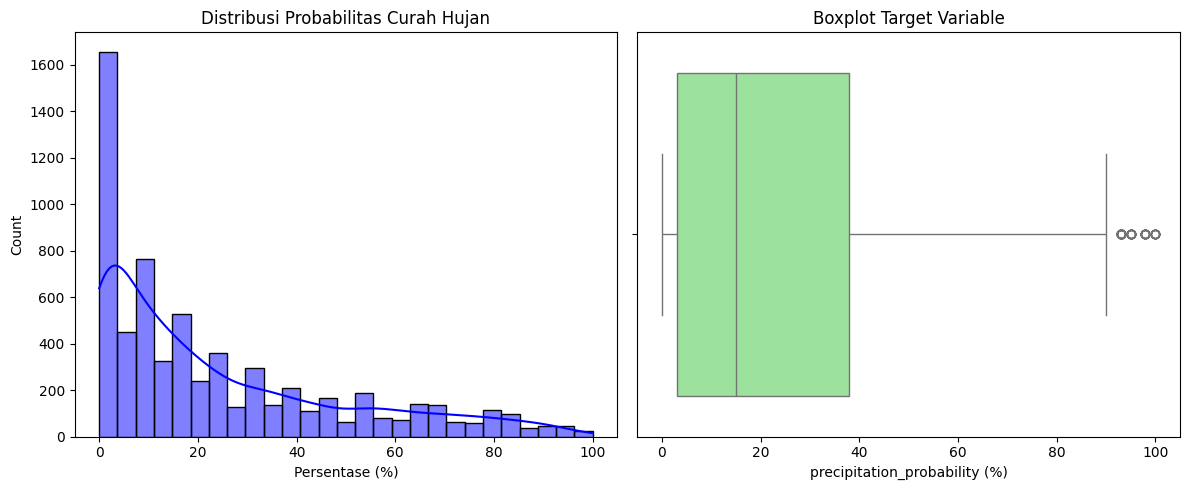

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_train[target_col], kde=True, color='blue')
plt.title('Distribusi Probabilitas Curah Hujan')
plt.xlabel('Persentase (%)')


plt.subplot(1, 2, 2)
sns.boxplot(x=df_train[target_col], color='lightgreen')
plt.title('Boxplot Target Variable')

plt.tight_layout()
plt.show()

## 4.2 Analisis Bivariat

### 4.2.1 Analisis rata-rata Probabilitas Hujan per Region

Analisis rata-rata probabilitas hujan per wilayah dilakukan untuk membedah pengaruh letak geografis terhadap intensitas curah hujan di setiap lokasi yang berbeda. Perbandingan antar daerah ini bertujuan untuk membuktikan adanya variasi pola cuaca lokal sehingga model dapat mempelajari karakteristik spesifik dari masing-masing wilayah secara lebih akurat.

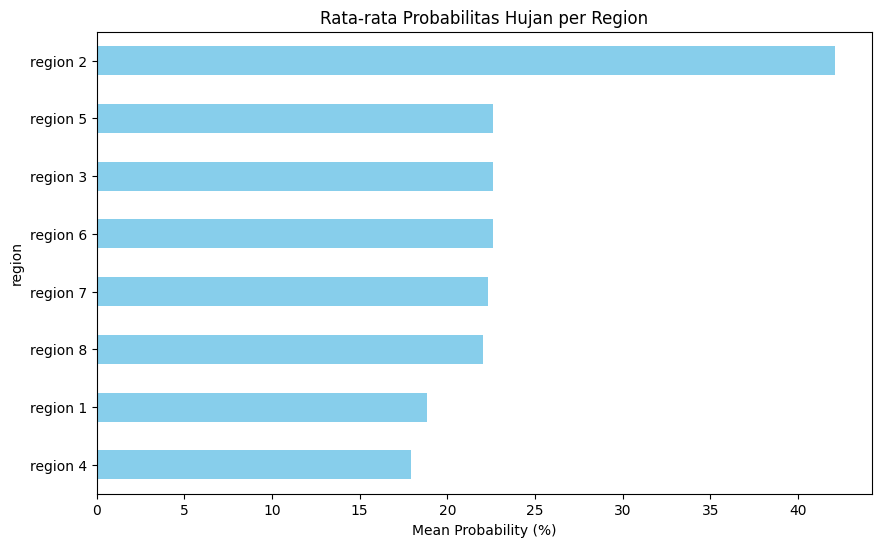

In [ ]:
plt.figure(figsize=(10, 6))
df_train.groupby('region')[target_col].mean().sort_values().plot(kind='barh', color='skyblue')
plt.title('Rata-rata Probabilitas Hujan per Region')
plt.xlabel('Mean Probability (%)')
plt.show()

### 4.2.2 Analisis Pengaruh Waktu terhadap Hujan

Analisis pengaruh waktu terhadap hujan dilakukan untuk mengidentifikasi pola temporal atau siklus harian yang memengaruhi fluktuasi probabilitas curah hujan. Dengan membedah data berdasarkan sesi waktu tertentu, kita dapat melihat kecenderungan apakah hujan lebih sering terjadi pada waktu-waktu spesifik seperti sore hari akibat proses konveksi atau malam hari karena pendinginan atmosfer.

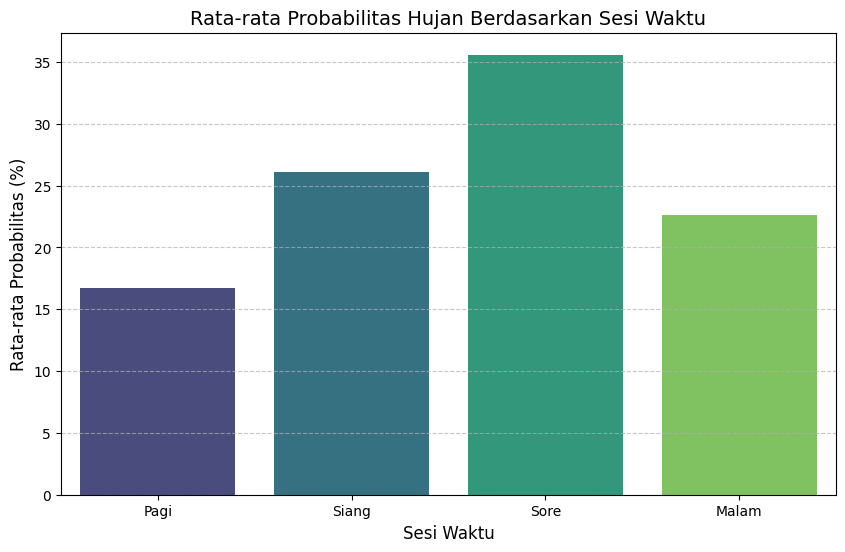

Tabel Rata-rata Probabilitas:
  time_session  precipitation_probability (%)
0         Pagi                      16.715074
1        Siang                      26.089154
2         Sore                      35.584559
3        Malam                      22.582353


In [ ]:
df_train['time'] = pd.to_datetime(df_train['time'])


df_train['hour'] = df_train['time'].dt.hour


def get_time_session(hour):
    if 5 <= hour < 11:
        return 'Pagi'
    elif 11 <= hour < 15:
        return 'Siang'
    elif 15 <= hour < 19:
        return 'Sore'
    else:
        return 'Malam'

df_train['time_session'] = df_train['hour'].apply(get_time_session)

session_order = ['Pagi', 'Siang', 'Sore', 'Malam']
df_train['time_session'] = pd.Categorical(df_train['time_session'], categories=session_order, ordered=True)


session_analysis = df_train.groupby('time_session')['precipitation_probability (%)'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=session_analysis, x='time_session', y='precipitation_probability (%)', palette='viridis')

plt.title('Rata-rata Probabilitas Hujan Berdasarkan Sesi Waktu', fontsize=14)
plt.xlabel('Sesi Waktu', fontsize=12)
plt.ylabel('Rata-rata Probabilitas (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Tabel Rata-rata Probabilitas:")
print(session_analysis)

## 4.3 Analisis Fitur Numerik

### 4.3.1 Analisis Korelasi Suhu dan Kelembapan terhadap Hujan
Pada bagian ini bertujuan untuk membedah interaksi antara suhu dan kelembapan sebagai indikator fisik utama dalam memicu terjadinya fenomena hujan

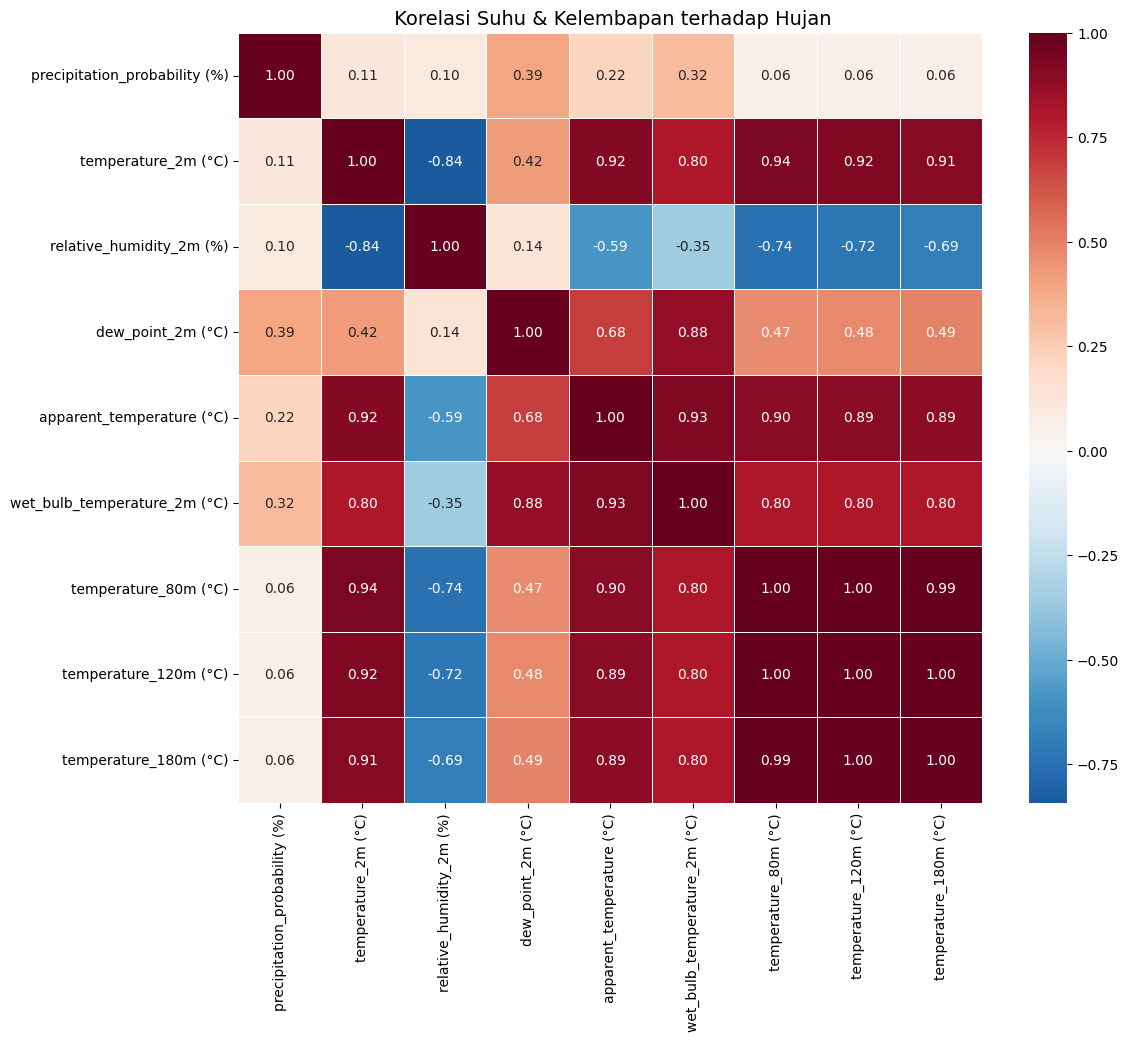

In [ ]:
thermo_cols = [
    'precipitation_probability (%)', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
    'dew_point_2m (°C)', 'apparent_temperature (°C)', 'wet_bulb_temperature_2m (°C)',
    'temperature_80m (°C)', 'temperature_120m (°C)', 'temperature_180m (°C)'
]


existing_cols = [c for c in thermo_cols if c in df_train.columns]
corr_matrix = df_train[existing_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title(' Korelasi Suhu & Kelembapan terhadap Hujan', fontsize=14)
plt.show()

### 4.3.2 Distribusi suhu dan kelembapan: Hujan dan cerah
membandingkan sebaran nilai suhu dan kelembapan untuk melihat perbedaan karakteristik yang kontras antara kondisi cuaca hujan dan cerah.

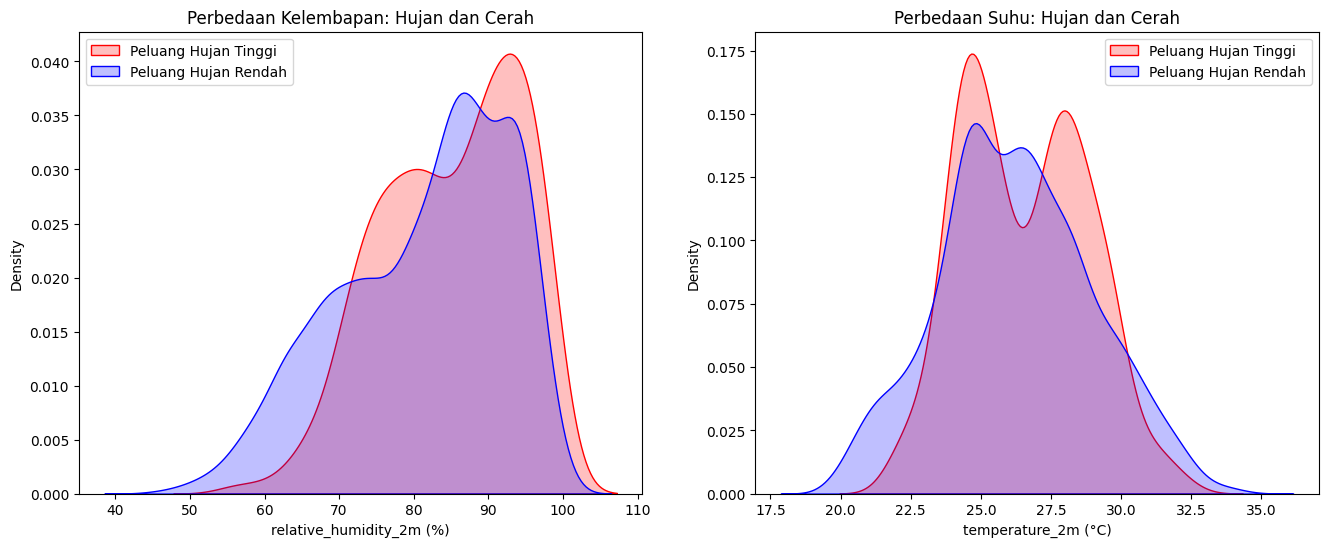

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(df_train[df_train['precipitation_probability (%)'] > 70]['relative_humidity_2m (%)'],
            ax=axes[0], fill=True, color='red', label='Peluang Hujan Tinggi')
sns.kdeplot(df_train[df_train['precipitation_probability (%)'] < 30]['relative_humidity_2m (%)'],
            ax=axes[0], fill=True, color='blue', label='Peluang Hujan Rendah')
axes[0].set_title('Perbedaan Kelembapan: Hujan dan Cerah')
axes[0].legend()


sns.kdeplot(df_train[df_train['precipitation_probability (%)'] > 70]['temperature_2m (°C)'],
            ax=axes[1], fill=True, color='red', label='Peluang Hujan Tinggi')
sns.kdeplot(df_train[df_train['precipitation_probability (%)'] < 30]['temperature_2m (°C)'],
            ax=axes[1], fill=True, color='blue', label='Peluang Hujan Rendah')
axes[1].set_title('Perbedaan Suhu: Hujan dan Cerah')
axes[1].legend()

plt.show()

### 4.3.2 Visualisasi Titik Jenuh (dew point)
dilakukan untuk menentukan suhu di mana udara menjadi jenuh dan uap air mulai berkondensasi menjadi butiran hujan. Melalui pemetaan fitur ini, kita dapat melihat seberapa dekat suhu aktual dengan titik jenuhnya, yang mana selisih yang semakin kecil biasanya menandakan probabilitas hujan yang sangat tinggi.

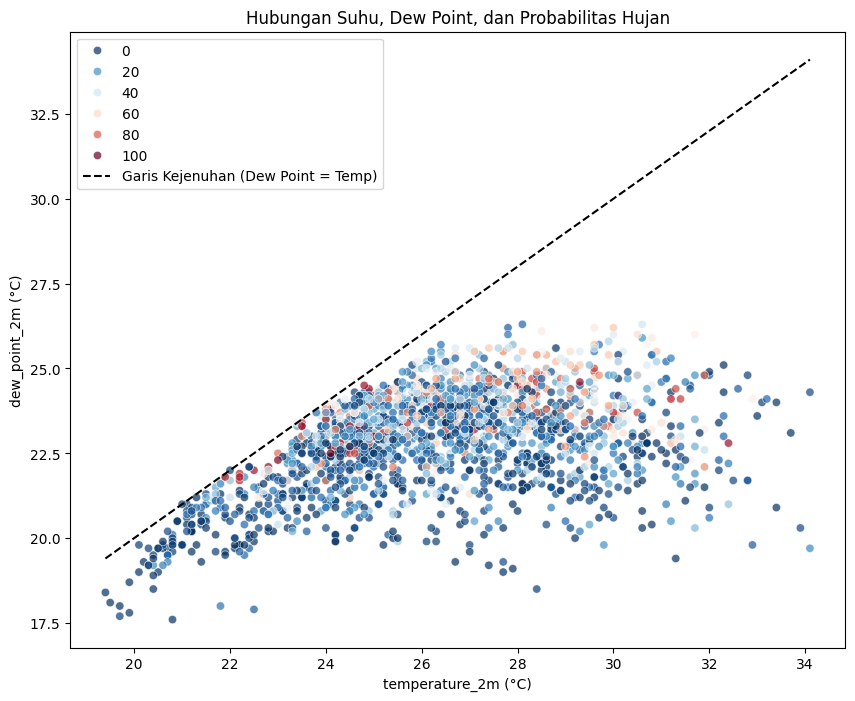

In [ ]:
plt.figure(figsize=(10, 8))

df_sample = df_train.sample(min(2000, len(df_train)))

sns.scatterplot(data=df_sample, x='temperature_2m (°C)', y='dew_point_2m (°C)',
                hue='precipitation_probability (%)', palette='RdBu_r', alpha=0.7)

plt.plot([df_sample['temperature_2m (°C)'].min(), df_sample['temperature_2m (°C)'].max()],
         [df_sample['temperature_2m (°C)'].min(), df_sample['temperature_2m (°C)'].max()],
         color='black', linestyle='--', label='Garis Kejenuhan (Dew Point = Temp)')

plt.title('Hubungan Suhu, Dew Point, dan Probabilitas Hujan')
plt.legend()
plt.show()

### 4.3.4 Analisis Profil Suhu Vertikal
dilakukan untuk membedah perbedaan struktur suhu di berbagai lapisan ketinggian atmosfer mulai dari permukaan 2 meter hingga 180 meter saat kondisi hujan dan cerah.

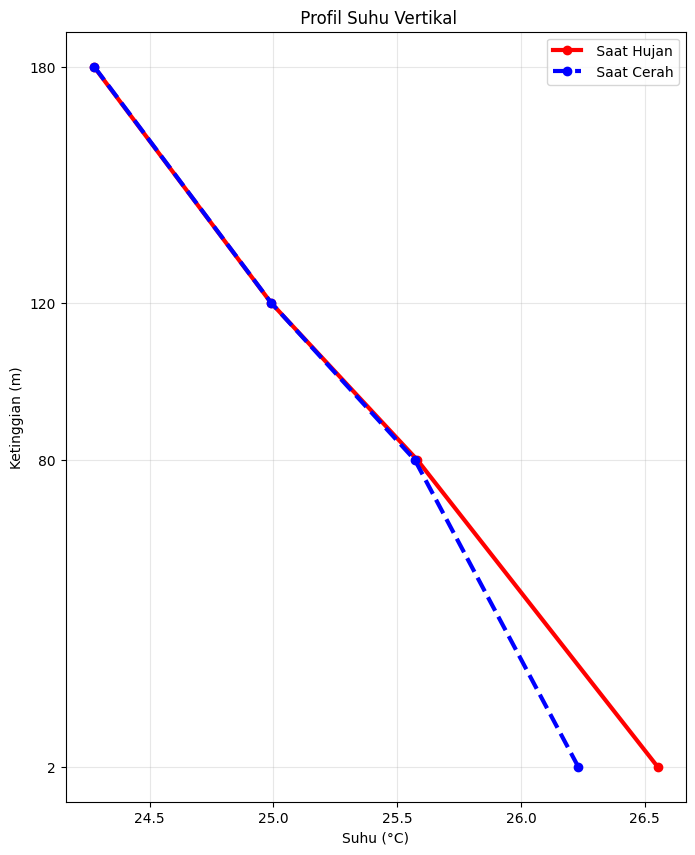

In [ ]:
heights = [2, 80, 120, 180]
temp_cols = ['temperature_2m (°C)', 'temperature_80m (°C)', 'temperature_120m (°C)', 'temperature_180m (°C)']

avg_temp_hujan = [df_train[df_train['precipitation_probability (%)'] > 70][c].mean() for c in temp_cols]
avg_temp_cerah = [df_train[df_train['precipitation_probability (%)'] < 30][c].mean() for c in temp_cols]

plt.figure(figsize=(8, 10))
plt.plot(avg_temp_hujan, heights, 'o-', color='red', label=' Saat Hujan', linewidth=3)
plt.plot(avg_temp_cerah, heights, 'o--', color='blue', label=' Saat Cerah', linewidth=3)

plt.ylabel('Ketinggian (m)')
plt.xlabel('Suhu (°C)')
plt.title(' Profil Suhu Vertikal')
plt.yticks(heights)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4.4 Distribusi Kode Cuaca

### 4.4.1 Distribusi Probabilitas Hujan berdasarkan Kode WMO
bertujuan untuk melihat variasi rentang nilai probabilitas pada setiap jenis fenomena cuaca yang terekam dalam kode WMO

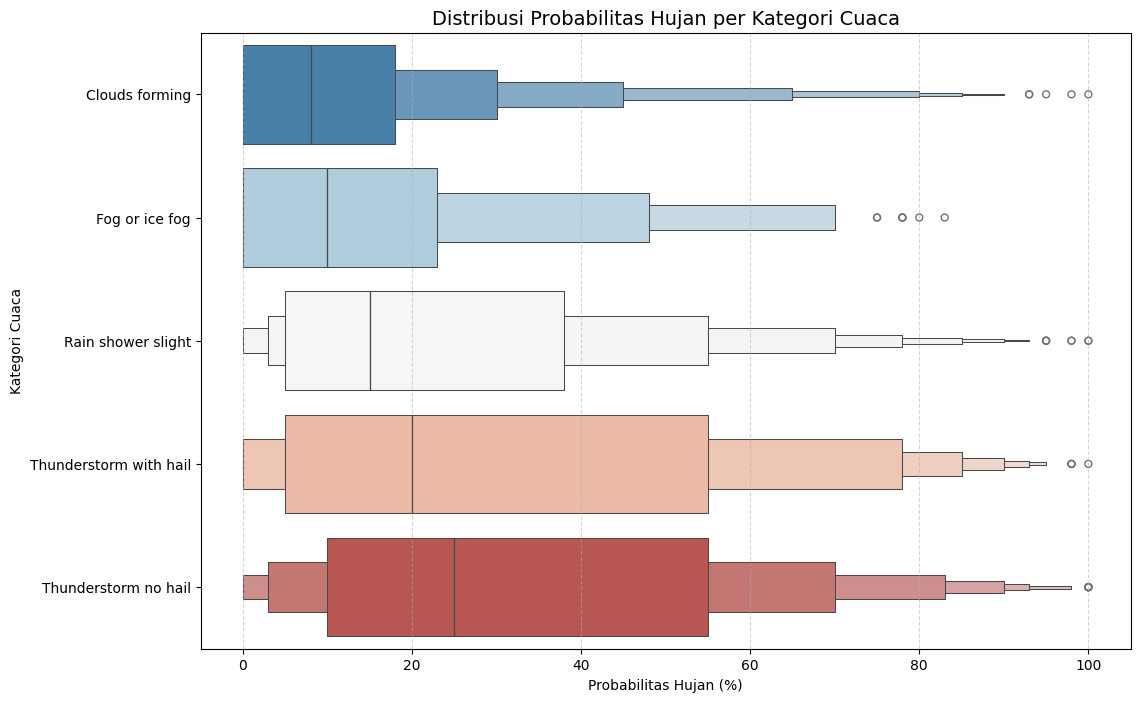

In [ ]:
if 'weather_category' in df_train.columns:
    plt.figure(figsize=(12, 8))

    order = df_train.groupby('weather_category')['precipitation_probability (%)'].median().sort_values().index

    sns.boxenplot(data=df_train, x='precipitation_probability (%)', y='weather_category',
                  order=order, palette='RdBu_r')

    plt.title('Distribusi Probabilitas Hujan per Kategori Cuaca', fontsize=14)
    plt.xlabel('Probabilitas Hujan (%)')
    plt.ylabel('Kategori Cuaca')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()

### 4.4.2 Klasifikasi Intensitas Fenomena Cuaca.
bertujuan untuk mengelompokkan kode-kode WMO yang tadinya berupa angka acak menjadi kategori intensitas yang lebih bermakna seperti Clear, Drizzle, Rain, atau Thunderstorm.Klasifikasi Intensitas Fenomena Cuaca

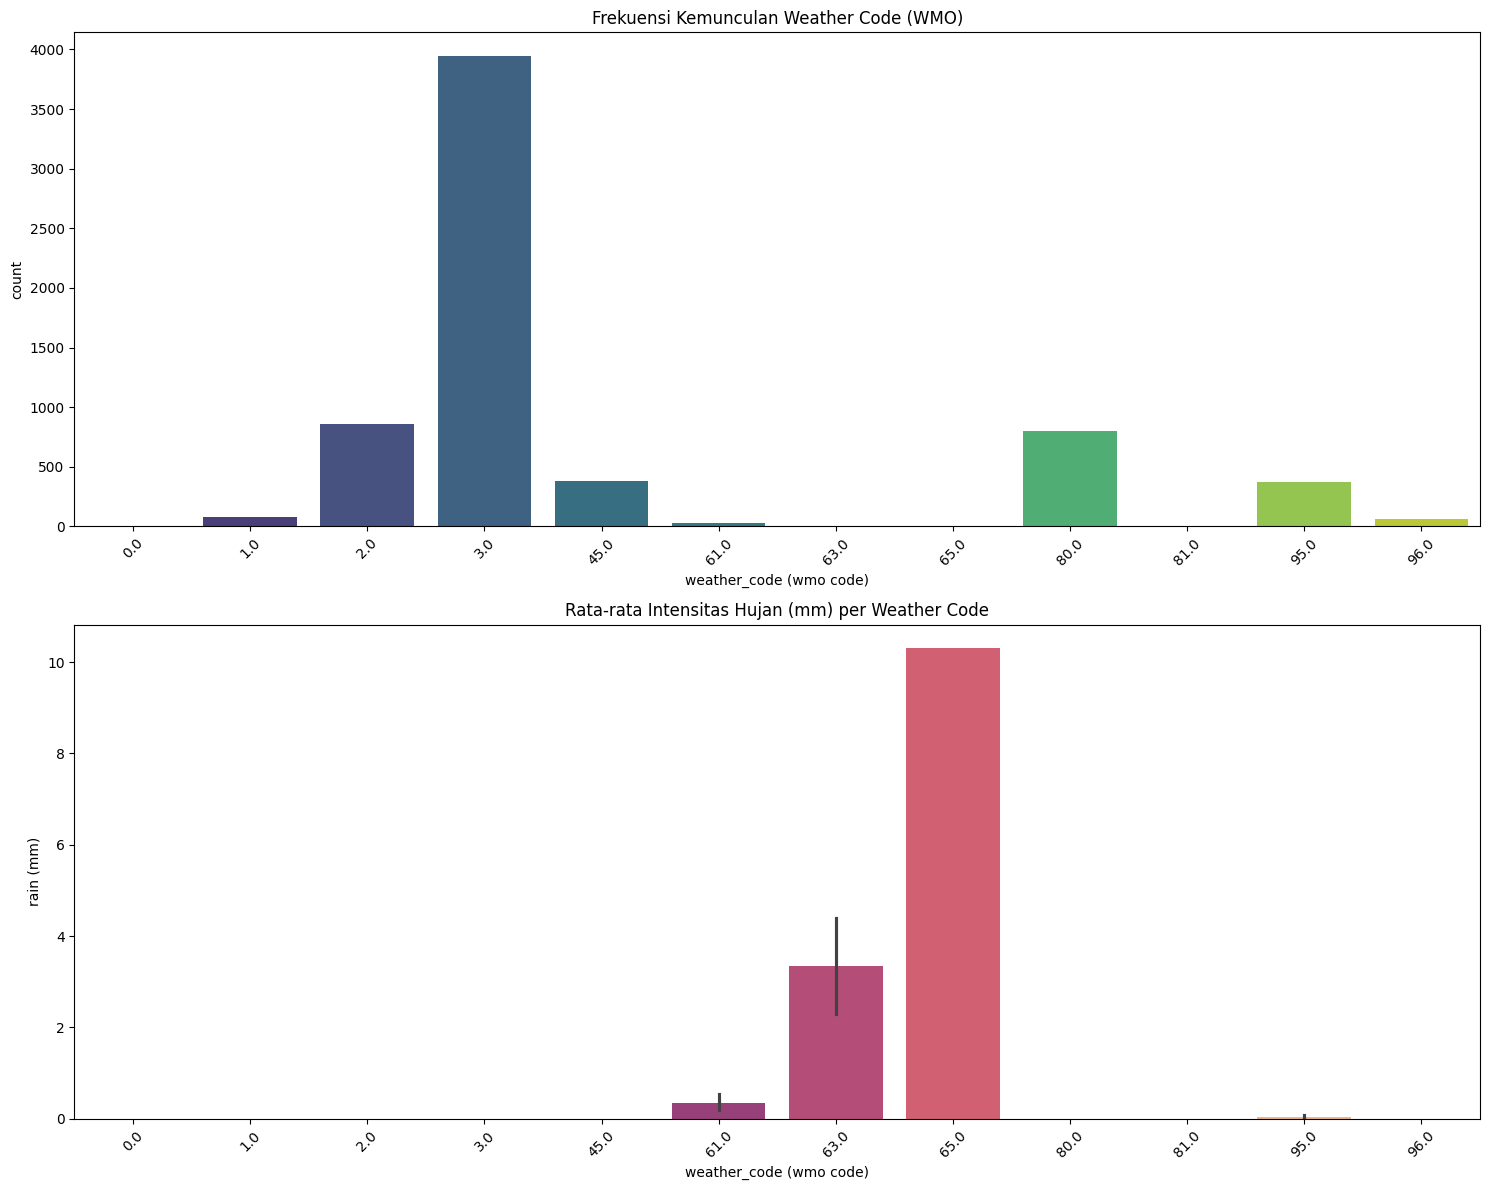

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))


sns.countplot(data=df_train, x='weather_code (wmo code)', ax=axes[0], palette='viridis')
axes[0].set_title('Frekuensi Kemunculan Weather Code (WMO)')
axes[0].tick_params(axis='x', rotation=45)


sns.barplot(data=df_train, x='weather_code (wmo code)', y='rain (mm)', ax=axes[1], palette='magma', estimator='mean')
axes[1].set_title('Rata-rata Intensitas Hujan (mm) per Weather Code')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4.5 Analisis Tekanan dan Atmosfer

### 4.5.1 Korelasi Struktur Atmosfer dengan Hujan
bertujuan untuk membedah hubungan antara struktur fisik atmosfer, seperti tekanan udara dan ketinggian lapisan batas (boundary layer), terhadap fluktuasi probabilitas hujan.

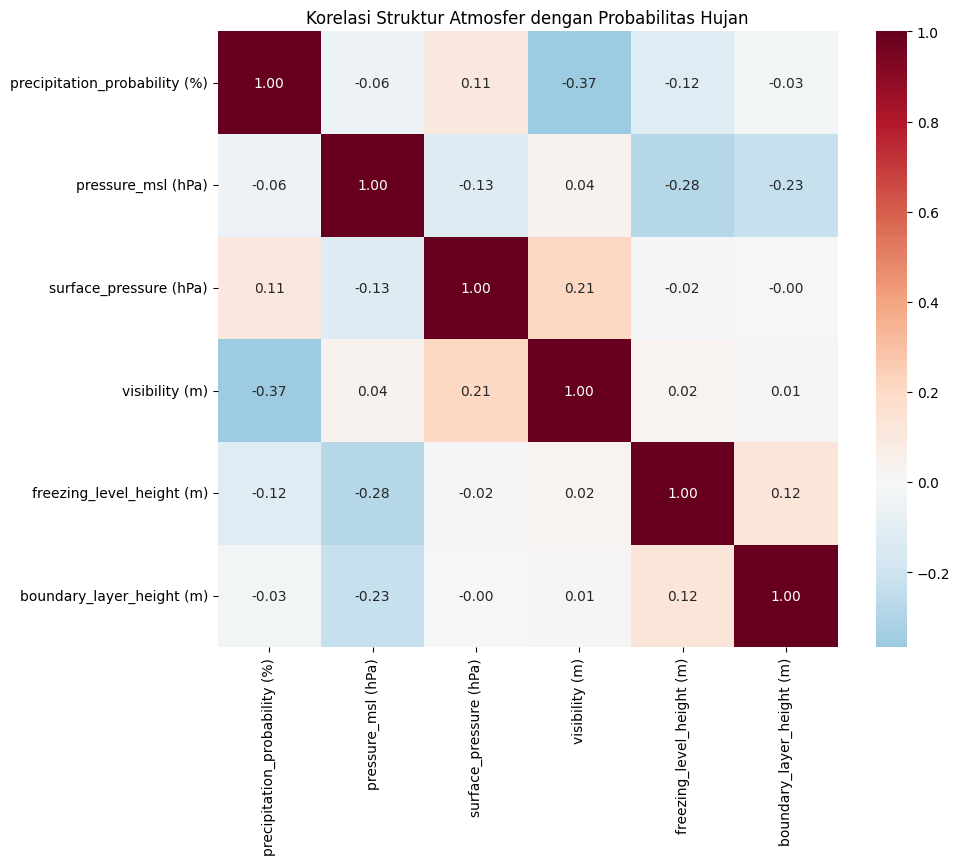

In [ ]:
atmos_vars = [
    'precipitation_probability (%)',
    'pressure_msl (hPa)',
    'surface_pressure (hPa)',
    'visibility (m)',
    'freezing_level_height (m)',
    'boundary_layer_height (m)'
]


plt.figure(figsize=(10, 8))
sns.heatmap(df_train[atmos_vars].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Korelasi Struktur Atmosfer dengan Probabilitas Hujan')
plt.show()

### 4.5.2 Analisis Karakteristik Visibilitas dan Lapisan Batas
dilakukan untuk memahami bagaimana kejernihan udara serta ketebalan lapisan atmosfer bawah berubah saat mendekati kondisi hujan.

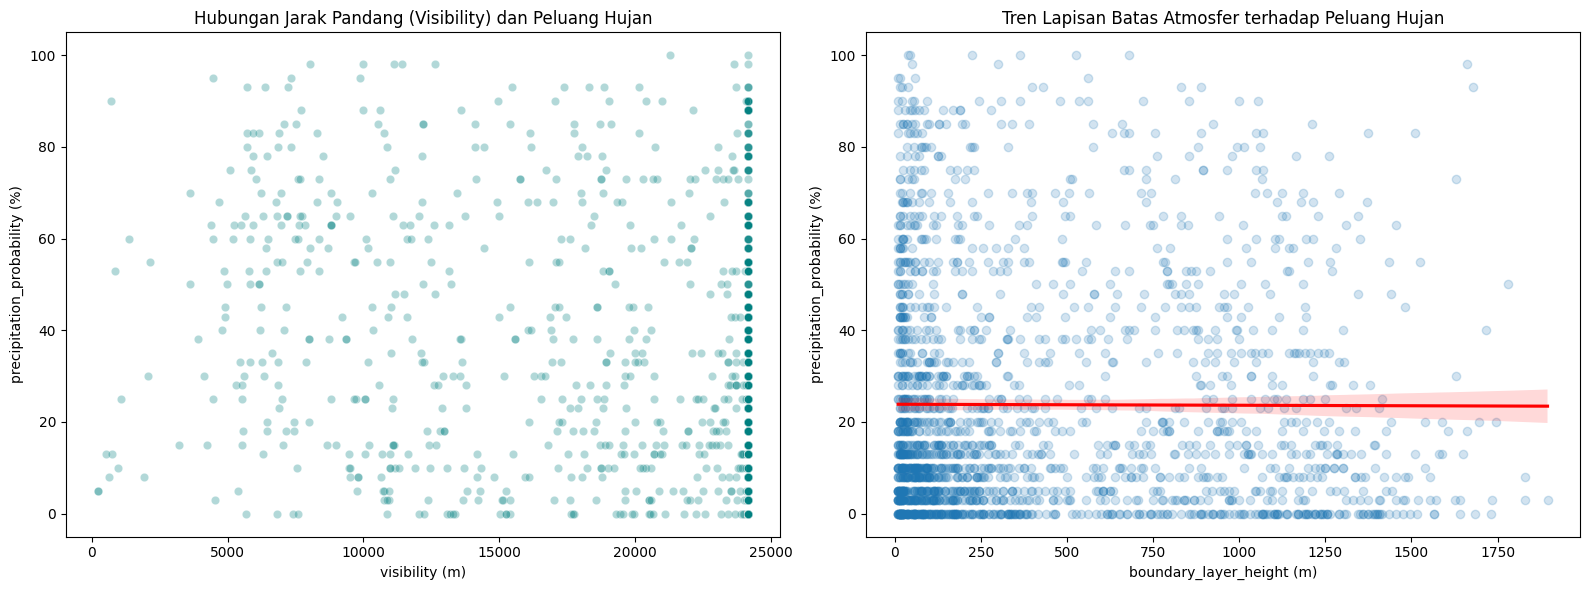

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(data=df_train.sample(min(2000, len(df_train))),
                x='visibility (m)', y='precipitation_probability (%)',
                alpha=0.3, color='teal', ax=axes[0])
axes[0].set_title('Hubungan Jarak Pandang (Visibility) dan Peluang Hujan')

sns.regplot(data=df_train.sample(min(2000, len(df_train))),
            x='boundary_layer_height (m)', y='precipitation_probability (%)',
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Tren Lapisan Batas Atmosfer terhadap Peluang Hujan')

plt.tight_layout()
plt.show()

### 4.5.2 Analisis Ketinggian Titik Beku terhadap Intensitas Hujan
Analisis ketinggian titik beku dilakukan untuk memantau batas vertikal di atmosfer di mana suhu udara mencapai $0°C$ dan kristal es mulai mencair menjadi tetesan air

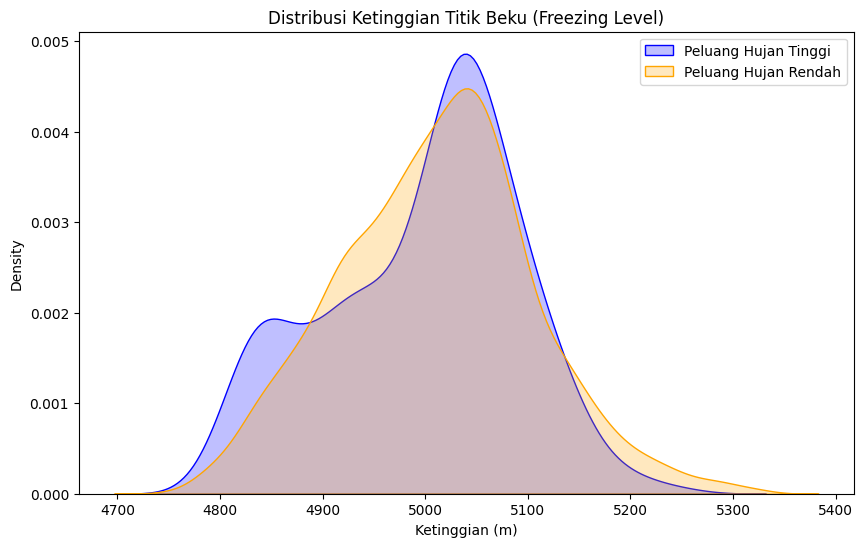

In [ ]:
plt.figure(figsize=(10, 6))


sns.kdeplot(df_train[df_train['precipitation_probability (%)'] > 70]['freezing_level_height (m)'],
            label='Peluang Hujan Tinggi', fill=True, color='blue')
sns.kdeplot(df_train[df_train['precipitation_probability (%)'] < 30]['freezing_level_height (m)'],
            label='Peluang Hujan Rendah', fill=True, color='orange')

plt.title('Distribusi Ketinggian Titik Beku (Freezing Level)')
plt.xlabel('Ketinggian (m)')
plt.legend()
plt.show()

## 4.6 Analisis Tutupan Awan
Analisis tutupan awan dilakukan untuk mengukur sejauh mana densitas awan di berbagai lapisan atmosfer memengaruhi peluang terjadinya presipitasi.

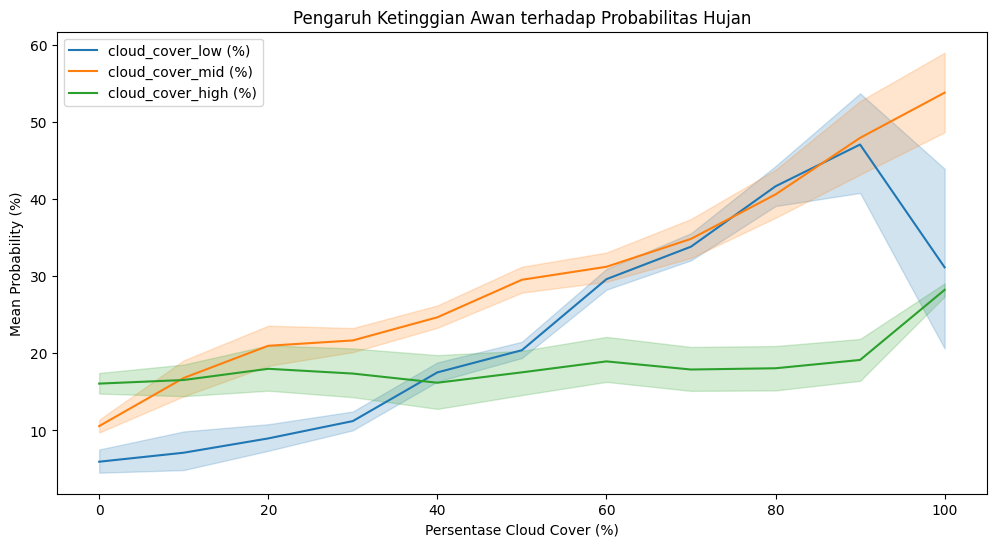

In [ ]:
cloud_features = ['cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)']

plt.figure(figsize=(12, 6))
for col in cloud_features:

    temp_df = df_train.copy()
    temp_df['cloud_bin'] = (temp_df[col] // 10) * 10
    sns.lineplot(data=temp_df, x='cloud_bin', y='precipitation_probability (%)', label=col)

plt.title('Pengaruh Ketinggian Awan terhadap Probabilitas Hujan')
plt.xlabel('Persentase Cloud Cover (%)')
plt.ylabel('Mean Probability (%)')
plt.legend()
plt.show()

## 4.7 Radiasi dan Evapotranspirasi
Analisis radiasi matahari dan evapotranspirasi dilakukan untuk memahami bagaimana suplai energi surya memacu proses penguapan yang menjadi bahan baku pembentukan awan hujan.

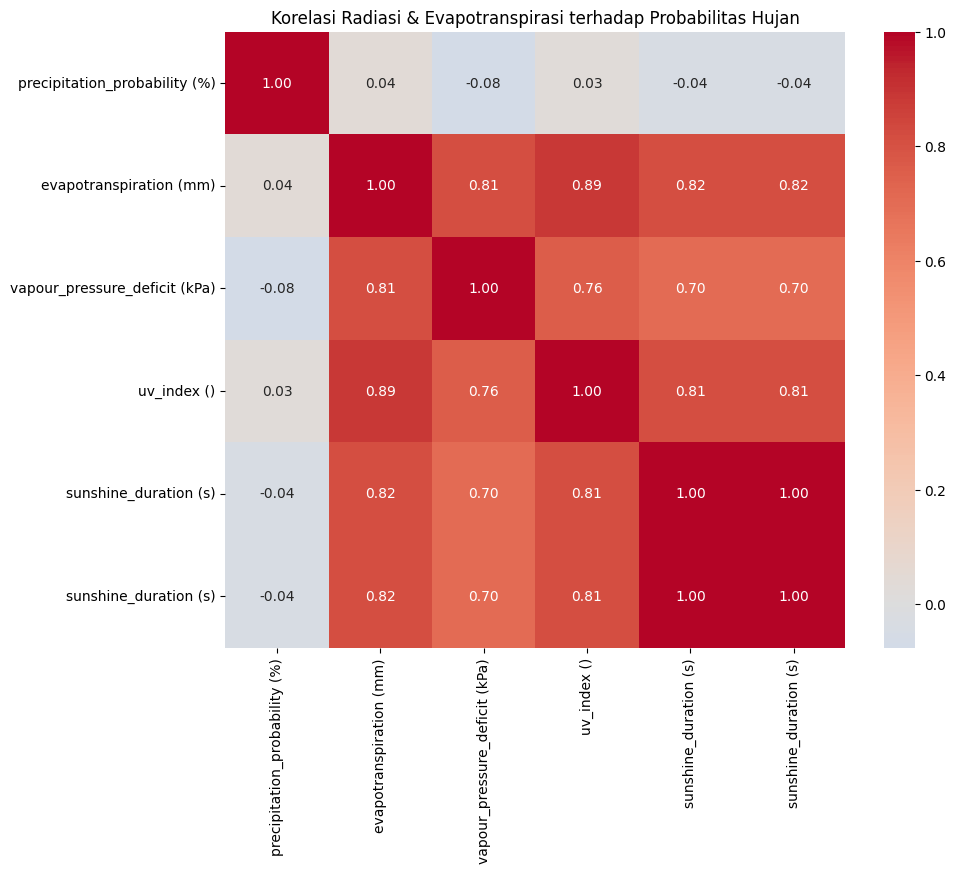

In [ ]:
radiation_evap_cols = [
    'precipitation_probability (%)', 'evapotranspiration (mm)',
    'vapour_pressure_deficit (kPa)', 'uv_index ()',
    'sunshine_duration (s)', 'sunshine_duration (s)'
]

corr_matrix = df_train[radiation_evap_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korelasi Radiasi & Evapotranspirasi terhadap Probabilitas Hujan')
plt.show()

## 4.8 Analisis Dinamika Angin terhadap Curah Hujan
Analisis dinamika angin dilakukan untuk mengevaluasi peran kecepatan dan arah angin dalam mendistribusikan uap air yang memicu terjadinya presipitasi.

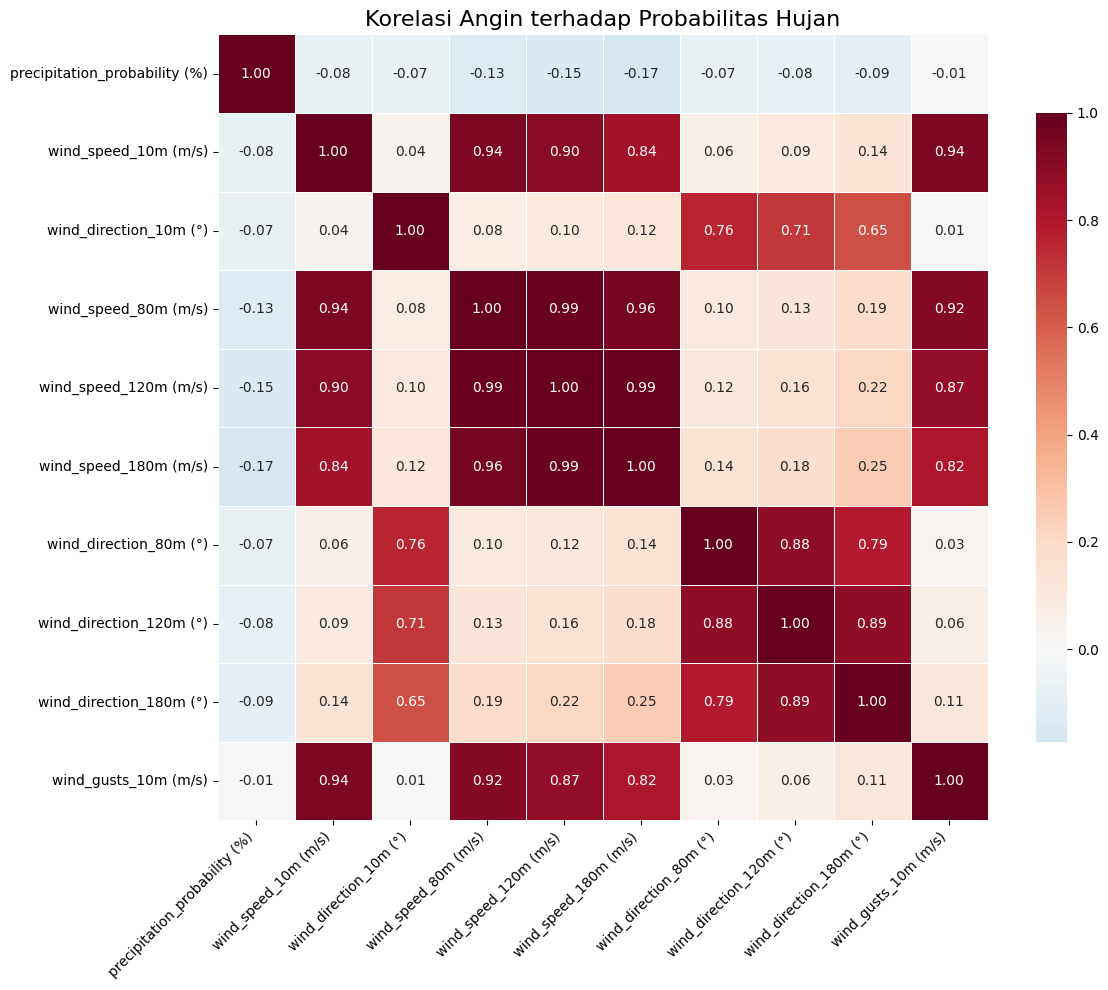

In [ ]:
wind_cols = [
    'precipitation_probability (%)',
    'wind_speed_10m (m/s)',
    'wind_direction_10m (°)',
    'wind_speed_80m (m/s)',
    'wind_speed_120m (m/s)',
    'wind_speed_180m (m/s)',
    'wind_direction_80m (°)',
    'wind_direction_120m (°)',
    'wind_direction_180m (°)',
    'wind_gusts_10m (m/s)'
]


existing_wind_cols = [c for c in wind_cols if c in df_train.columns]

corr_wind = df_train[existing_wind_cols].corr()


plt.figure(figsize=(12, 10))
sns.heatmap(corr_wind,
            annot=True,
            cmap='RdBu_r',
            center=0,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Korelasi Angin terhadap Probabilitas Hujan', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.8.1 Visualisasi Distribusi dan Arah Angin
Analisis visual ini menggunakan kombinasi wind rose dan scatter plot untuk memetakan bagaimana kecepatan serta arah angin berkorelasi dengan intensitas probabilitas hujan

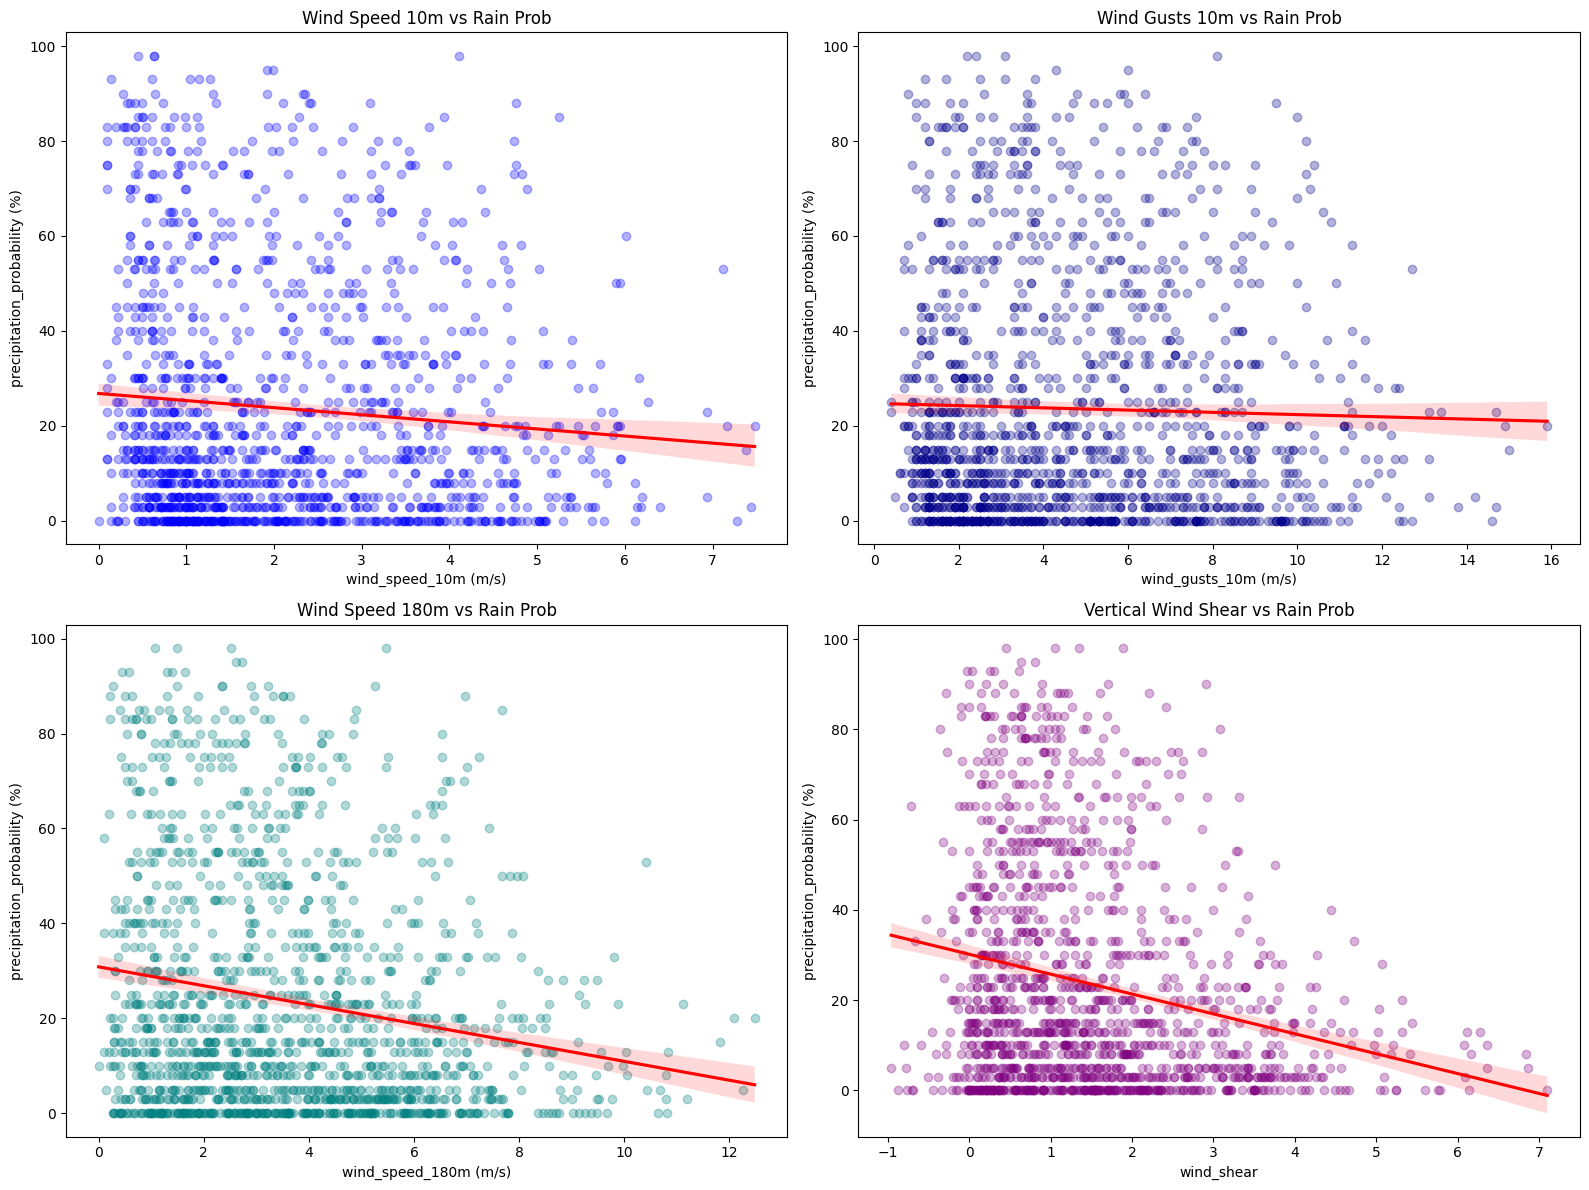

In [ ]:
df_sample = df_train.sample(min(1500, len(df_train)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


sns.regplot(ax=axes[0, 0], data=df_sample, x='wind_speed_10m (m/s)', y='precipitation_probability (%)',
            scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'red'})
axes[0, 0].set_title('Wind Speed 10m vs Rain Prob')


sns.regplot(ax=axes[0, 1], data=df_sample, x='wind_gusts_10m (m/s)', y='precipitation_probability (%)',
            scatter_kws={'alpha':0.3, 'color':'darkblue'}, line_kws={'color':'red'})
axes[0, 1].set_title('Wind Gusts 10m vs Rain Prob')

sns.regplot(ax=axes[1, 0], data=df_sample, x='wind_speed_180m (m/s)', y='precipitation_probability (%)',
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
axes[1, 0].set_title('Wind Speed 180m vs Rain Prob')


df_sample['wind_shear'] = df_sample['wind_speed_180m (m/s)'] - df_sample['wind_speed_10m (m/s)']

sns.regplot(ax=axes[1, 1], data=df_sample, x='wind_shear', y='precipitation_probability (%)',
            scatter_kws={'alpha':0.3, 'color':'purple'}, line_kws={'color':'red'})
axes[1, 1].set_title('Vertical Wind Shear vs Rain Prob')

plt.tight_layout()
plt.show()

### 4.8.2 Profil Kecepatan Angin Vertikal.
Analisis profil angin vertikal dilakukan untuk membedah perbedaan struktur kecepatan aliran udara pada berbagai lapisan ketinggian

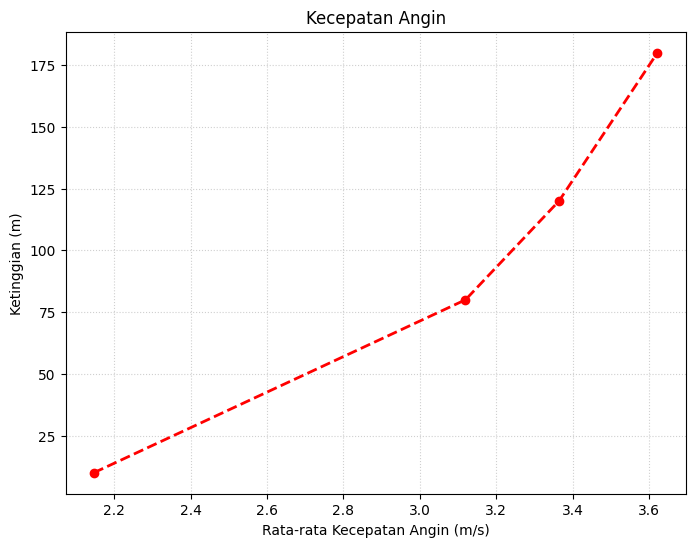

In [ ]:
heights = [10, 80, 120, 180]
avg_speeds = [
    df_train['wind_speed_10m (m/s)'].mean(),
    df_train['wind_speed_80m (m/s)'].mean(),
    df_train['wind_speed_120m (m/s)'].mean(),
    df_train['wind_speed_180m (m/s)'].mean()
]

plt.figure(figsize=(8, 6))
plt.plot(avg_speeds, heights, marker='o', linestyle='--', color='red', linewidth=2)
plt.xlabel('Rata-rata Kecepatan Angin (m/s)')
plt.ylabel('Ketinggian (m)')
plt.title('Kecepatan Angin')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 5. Data Prepocessing
Proses ini bertujuan untuk menghilangkan derau (noise), menangani ketidakkonsistenan sensor, dan mengekstrak informasi laten yang dapat meningkatkan performa prediktif model ensemble.

## 5.1 Data Cleaning
Pembersihan data dilakukan untuk menjamin bahwa model machine learning tidak mempelajari pola dari data yang rusak atau tidak valid

### 5.1.1 Penanganan Nilai Hilang melalui Interpolasi
Penanganan nilai hilang dilakukan dengan metode interpolasi linear untuk menjaga kontinuitas temporal pada parameter cuaca yang bersifat sekuensial. Teknik ini mengestimasi data yang kosong dengan menarik garis lurus di antara dua titik waktu yang tersedia, sehingga fluktuasi alami atmosfer seperti transisi suhu tetap terjaga

In [ ]:
def interpolasi(df):
    df = df.sort_values(['region', 'time'])

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'precipitation_probability (%)' in num_cols:
        num_cols.remove('precipitation_probability (%)')

    df[num_cols] = df.groupby('region')[num_cols].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

    return df

## 5.2 Feature Enginering
Tahap ini bertujuan untuk menciptakan variabel baru dari data yang ada guna membantu model menangkap pola cuaca yang lebih kompleks dan non-linear.

### 5.2.1 Rekayasa Fitur Dinamika Angin
Fitur ini melakukan transformasi komprehensif pada data angin dengan mengonversi arah dan kecepatan di berbagai ketinggian menjadi komponen vektor $U$ dan $V$ guna menghilangkan diskontinuitas numerik pada sudut derajat.

In [ ]:
def fitur_engineering_Angin(df):

    levels = ['10m', '80m', '120m', '180m']

    for lvl in levels:
        speed_col = f'wind_speed_{lvl} (m/s)'
        dir_col = f'wind_direction_{lvl} (°)'

        if speed_col in df.columns and dir_col in df.columns:

            rad = np.deg2rad(df[dir_col])

            df[f'wind_u_{lvl}'] = df[speed_col] * np.cos(rad)
            df[f'wind_v_{lvl}'] = df[speed_col] * np.sin(rad)


            df[f'wind_dir_sin_{lvl}'] = np.sin(rad)
            df[f'wind_dir_cos_{lvl}'] = np.cos(rad)


    if 'wind_speed_180m (m/s)' in df.columns and 'wind_speed_10m (m/s)' in df.columns:
        df['vertical_shear_total'] = df['wind_speed_180m (m/s)'] - df['wind_speed_10m (m/s)']
        df['vertical_shear_low'] = df['wind_speed_80m (m/s)'] - df['wind_speed_10m (m/s)']


    if 'wind_gusts_10m (m/s)' in df.columns and 'wind_speed_10m (m/s)' in df.columns:
        df['gust_factor'] = df['wind_gusts_10m (m/s)'] / (df['wind_speed_10m (m/s)'] + 1)

        df['wind_energy'] = 0.5 * (df['wind_speed_10m (m/s)'] ** 2)

    return df


df_train = fitur_engineering_Angin(df_train)
df_test = fitur_engineering_Angin(df_test)

### 5.2.2 Fitur Suhu Kelembapan dan Cuaca
Rekayasa fitur pada parameter termal dan higrometrik dilakukan dengan menghitung selisih suhu antar ketinggian serta tingkat kejenuhan uap air untuk mengidentifikasi stabilitas lapisan atmosfer bawah

In [ ]:
def fitur_suhu_kelembapan(df):

    if 'temperature_2m (°C)' in df.columns and 'dew_point_2m (°C)' in df.columns:
        df['dew_point_spread'] = df['temperature_2m (°C)'] - df['dew_point_2m (°C)']

    if 'temperature_2m (°C)' in df.columns and 'temperature_180m (°C)' in df.columns:
        df['temp_gradient_total'] = df['temperature_2m (°C)'] - df['temperature_180m (°C)']
        df['temp_gradient_low'] = df['temperature_2m (°C)'] - df['temperature_80m (°C)']

    if 'apparent_temperature (°C)' in df.columns:
        df['heat_stress'] = df['apparent_temperature (°C)'] - df['temperature_2m (°C)']

    if 'wet_bulb_temperature_2m (°C)' in df.columns:
        df['wet_bulb_depression'] = df['temperature_2m (°C)'] - df['wet_bulb_temperature_2m (°C)']


    if 'relative_humidity_2m (%)' in df.columns:
        df['is_high_humidity'] = (df['relative_humidity_2m (%)'] > 85).astype(int)


        df['humidity_trend'] = df.groupby('region')['relative_humidity_2m (%)'].diff(1).fillna(0)

    return df


df_train = fitur_suhu_kelembapan(df_train)
df_test = fitur_suhu_kelembapan(df_test)

In [ ]:
def cuaca(df):

    df['dew_point_depression'] = df['temperature_2m (°C)'] - df['dew_point_2m (°C)']

    df['temp_gradient_80m'] = df['temperature_2m (°C)'] - df['temperature_80m (°C)']

    df['apparent_diff'] = df['apparent_temperature (°C)'] - df['temperature_2m (°C)']

    return df

df_train = cuaca(df_train)
df_test = cuaca (df_test)

### 5.2.3 Fitur Temporal (Pengelompokan Waktu berdasarkan Sesi)
fitur berbasis sesi waktu dilakukan untuk mengelompokkan data ke dalam kategori pagi, siang, sore, dan malam guna menangkap karakteristik termal dan radiasi matahari yang khas pada setiap periode.

In [ ]:
def create_session(df):

    df['time'] = pd.to_datetime(df['time'])
    hour = df['time'].dt.hour

    df['time_session'] = pd.cut(hour,
                                bins=[-1, 5, 11, 17, 24],
                                labels=['Malam', 'Pagi', 'Siang', 'Sore'])
    return df

df_train = create_session(df_train)
df_test = create_session(df_test)

### 5.2.4 Fitur Transformasi Waktu Siklis
Transformasi siklis menggunakan fungsi trigonometri diterapkan untuk memetakan fitur waktu ke dalam koordinat lingkaran sehingga hubungan periodik antara akhir dan awal siklus tetap terjaga secara matematis. Melalui komponen sinus dan kosinus, model dapat mengenali bahwa jam 23:00 dan 00:00 memiliki kedekatan temporal yang nyata, berbeda dengan representasi linear yang menganggap keduanya sebagai titik ekstrem yang berjauhan.

In [ ]:
def create_time_features(df):
    df['time'] = pd.to_datetime(df['time'])
    df['hour'] = df['time'].dt.hour

    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    return df

df_train = create_time_features(df_train)
df_test = create_time_features(df_test)

### 5.2.5 Fitur Radiasi dan Evapotranspirasi
fitur radiasi dan evapotranspirasi bertujuan untuk mengukur intensitas energi matahari yang mencapai permukaan serta laju penguapan air yang menjadi bahan baku pembentukan awan.

In [ ]:
def fitur_engineering_Radiasi(df):
    df['uv_diff'] = df['uv_index_clear_sky ()'] - df['uv_index ()']


    df['sunshine_ratio'] = df['sunshine_duration (s)'] / 3600.0

    df['et_ratio'] = df['evapotranspiration (mm)'] / (df['et0_fao_evapotranspiration (mm)'] + 1e-5)


    df['evap_potential'] = df['vapour_pressure_deficit (kPa)'] * df['uv_index ()']

    df['et_diff'] = df['evapotranspiration (mm)'] - df['et0_fao_evapotranspiration (mm)']

    return df

df_train = fitur_engineering_Radiasi(df_train)
df_test = fitur_engineering_Radiasi(df_test)

### 5.2.6 Fitur lag
fitur lag dilakukan untuk memberikan konteks historis kepada model dengan memasukkan nilai parameter cuaca dari satu hingga tiga jam sebelumnya sebagai prediktor tambahan. Teknik ini memungkinkan algoritma untuk menangkap tren perubahan jangka pendek.

In [ ]:
def lag_fitur(df):

    df = df.sort_values(['region', 'time'])

    target_sensors = [
        'precipitation (mm)',
        'temperature_2m (°C)',
        'relative_humidity_2m (%)',
        'cloud_cover (%)',
        'vapour_pressure_deficit (kPa)',
        'evapotranspiration (mm)',
        'uv_index () '

    ]


    for col in target_sensors:
        if col in df.columns:

            df[f'{col}_lag1'] = df.groupby('region')[col].shift(1)

            df[f'{col}_lag3'] = df.groupby('region')[col].shift(3)

            df[f'{col}_trend'] = df[col] - df[f'{col}_lag1']


    lag_cols = [c for c in df.columns if 'lag' in c or 'trend' in c]
    df[lag_cols] = df[lag_cols].fillna(0)

    return df

df_train = lag_fitur(df_train)
df_test = lag_fitur(df_test)


### 5.2.7 Fitur Moving Average
dilakukan dengan menghitung nilai rata-rata parameter cuaca selama rentang waktu 3 hingga 6 jam terakhir untuk menangkap tren akumulasi energi dan kelembapan secara kontinu

In [ ]:
def fitur_ratarata(df):

    df = df.sort_values(['region', 'time'])

    rolling_cols = ['temperature_2m (°C)', 'relative_humidity_2m (%)', 'surface_pressure (hPa)','vapour_pressure_deficit (kPa)']

    for col in rolling_cols:
        if col in df.columns:

            df[f'{col}_roll_mean_3h'] = df.groupby('region')[col].transform(
                lambda x: x.rolling(window=3, min_periods=1).mean()
            )

            df[f'{col}_roll_mean_6h'] = df.groupby('region')[col].transform(
                lambda x: x.rolling(window=6, min_periods=1).mean()
            )

            df[f'{col}_roll_std_3h'] = df.groupby('region')[col].transform(
                lambda x: x.rolling(window=3, min_periods=1).std()
            )


    roll_cols = [c for c in df.columns if 'roll_' in c]
    df[roll_cols] = df[roll_cols].fillna(0)

    return df


df_train = fitur_ratarata(df_train)
df_test = fitur_ratarata(df_test)

### 5.2.8 Fitur Tutupan Awan
dilakukan untuk menganalisis kepadatan massa awan di berbagai lapisan atmosfer, mulai dari level rendah hingga tinggi, sebagai indikator utama penghalang radiasi matahari.

In [ ]:
def fitur_tutupan_awan(df):

    cloud_levels = ['cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)']
    existing_levels = [c for c in cloud_levels if c in df.columns]

    if len(existing_levels) > 0:

        df['avg_cloud_all_levels'] = df[existing_levels].mean(axis=1)

        df['cloud_density_score'] = df[existing_levels].sum(axis=1)

    if 'cloud_cover_low (%)' in df.columns and 'cloud_cover_high (%)' in df.columns:
        df['low_high_cloud_diff'] = df['cloud_cover_low (%)'] - df['cloud_cover_high (%)']


    if 'cloud_cover (%)' in df.columns and 'uv_index' in df.columns:
        df['cloud_darkness'] = df['cloud_cover (%)'] / (df['uv_index'] + 1)

    df = df.sort_values(['region', 'time'])
    df['cloud_trend_1h'] = df.groupby('region')['cloud_cover (%)'].diff(1).fillna(0)


    df['cloud_roll_3h'] = df.groupby('region')['cloud_cover (%)'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )

    return df


df_train = fitur_tutupan_awan(df_train)
df_test = fitur_tutupan_awan(df_test)

### 5.2.9 Fitur Tekanan dan Atmosfer
fitur tekanan dan atmosfer dilakukan untuk menangkap fluktuasi tekanan udara permukaan serta selisih tekanan antar ketinggian yang mengindikasikan adanya sistem tekanan rendah atau konvergensi.

In [ ]:
def fitur_tekanan_atmosfer(df):

    df = df.sort_values(['region', 'time'])

    df['pressure_diff_msl_surface'] = df['pressure_msl (hPa)'] - df['surface_pressure (hPa)']

    df['pressure_msl_diff_1h'] = df.groupby('region')['pressure_msl (hPa)'].diff(1).fillna(0)
    df['pressure_msl_diff_3h'] = df.groupby('region')['pressure_msl (hPa)'].diff(3).fillna(0)


    df['is_low_visibility'] = (df['visibility (m)'] < 5000).astype(int)
    df['visibility_log'] = np.log1p(df['visibility (m)'])

    df['freezing_level_diff_3h'] = df.groupby('region')['freezing_level_height (m)'].diff(3).fillna(0)


    df['bl_freezing_ratio'] = df['boundary_layer_height (m)'] / (df['freezing_level_height (m)'] + 1)

    return df


df_train = fitur_tekanan_atmosfer(df_train)
df_test = fitur_tekanan_atmosfer(df_test)

# 6. Modeling

## 6.1 Pelatihan Model Ensemble dengan Voting Regressor
Tahap pemodelan ini menggunakan pendekatan Ensemble Learning dengan metode Voting Regressor yang mengombinasikan kekuatan dari empat algoritma berbasis pohon (Random Forest, XGBoost, LightGBM, dan CatBoost) untuk memprediksi probabilitas presipitasi.

In [ ]:
cat_cols = ['region', 'weather_category', 'time_session']
le = LabelEncoder()

for col in cat_cols:
    if col in df_train.columns:
        combined = pd.concat([df_train[col], df_test[col]], axis=0).astype(str)
        le.fit(combined)
        df_train[col] = le.transform(df_train[col].astype(str))
        df_test[col] = le.transform(df_test[col].astype(str))


drop_cols = ['ID', 'time', 'precipitation_probability (%)']
X = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
y = df_train['precipitation_probability (%)']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=70)

rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=86, n_jobs=-1)


xgb = XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=7,
                   eval_metric='rmse', random_state=56, tree_method='hist')

lgbm = LGBMRegressor(n_estimators=1000, learning_rate=0.03, num_leaves=63,
                     metric='rmse', random_state=11, verbose=-1)

cat = CatBoostRegressor(iterations=1000, learning_rate=0.03, depth=7,
                        loss_function='RMSE', random_state=66, verbose=0)

ensemble = VotingRegressor(estimators=[
    ('rf', rf),
    ('xgb', xgb),
    ('lgbm', lgbm),
    ('cat', cat)
], weights=[1, 1.5, 2, 2])


print("Training Ensemble Model")
ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("-" * 35)
print(f"Hasil Validasi RMSE: {rmse:.4f}")
print("-" * 35)

Training Ensemble Model
-----------------------------------
Hasil Validasi RMSE: 9.7921
-----------------------------------


## 6.2 K-Fold Cross-Validation
Evaluasi model dilakukan menggunakan metode K-Fold Cross-Validation untuk menguji stabilitas dan reliabilitas prediksi pada berbagai subset data yang berbeda.

In [ ]:
feature_names = X.columns.tolist()
X_test = df_test[feature_names]


kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_rmse = []



for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    model_fold = VotingRegressor(estimators=[
        ('rf', rf), ('xgb', xgb), ('lgbm', lgbm), ('cat', cat)
    ], weights=[1, 1.5, 2, 2])


    model_fold.fit(X_tr, y_tr)

    fold_pred = model_fold.predict(X_va)
    fold_pred = np.clip(fold_pred, 0, 100)
    oof_preds[val_idx] = fold_pred


    test_preds += model_fold.predict(X_test) / kf.n_splits

    score = np.sqrt(mean_squared_error(y_va, fold_pred))
    fold_rmse.append(score)

    print(f"Fold {fold+1} | RMSE: {score:.4f}")

Fold 1 | RMSE: 10.4546
Fold 2 | RMSE: 10.2429
Fold 3 | RMSE: 9.9938
Fold 4 | RMSE: 10.2022
Fold 5 | RMSE: 9.8445


# 7 Submisi
submisi dilakukan dengan mengaplikasikan model ensemble final pada dataset pengujian untuk menghasilkan prediksi probabilitas presipitasi bagi setiap observasi. Nilai prediksi tersebut kemudian dipetakan kembali ke identitas unik masing-masing baris (ID) untuk memastikan integritas data saat penggabungan hasil

In [ ]:
feature_names = X.columns.tolist()
X_test = df_test[feature_names]

print("prediksi akhir")
test_preds = ensemble.predict(X_test)

test_preds = np.clip(test_preds, 0, 100)


df_submission = pd.DataFrame({
    'ID': df_test['ID'],
    'precipitation_probability (%)': test_preds
})


file_name = 'submission.csv'
df_submission.to_csv(file_name, index=False)

prediksi akhir
